# Pension vs Index Decision Analysis

This notebook compares a regular index fund with a `plan_de_pensiones` for the specific analyses below:

1. Pension advantage heatmap by salary during working years and salary before extraction during retirement.
2. Fee-vs-annual-return heatmaps for a configurable `10,000` EUR/year scenario at 3% and 4% extraction rates.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from pension_vs_index.analysis import (
    ScenarioConfig,
    lump_sum_results,
    normalize_lump_sum_extraction_results,
    normalize_percentage_extraction_results,
    percentage_fee_return_sensitivity_grid_results,
    percentage_withdrawal_results,
    simulate_all_accumulation,
    working_retirement_salary_sensitivity_results,
)
from pension_vs_index.visualization import (
    plot_accumulation_history,
    plot_extraction_comparison_breakdown,
    plot_fee_return_sensitivity,
    plot_salary_heatmaps,
)

pd.options.display.float_format = "{:,.2f}".format
plt.style.use("seaborn-v0_8-whitegrid")

## Editable assumptions

Change these dictionaries before running the analysis. Values under `config` are fixed parameters for that experiment. Values under `heatmap` are the variables swept by that graph, so they are intentionally not repeated in `config`.


In [2]:
PRIMARY_SCENARIO = {
    "name": "10k/year, 60k working salary, 47k retirement salary, 40 years",
    "config": {
        "gross_salary_during_contribution": 60_000.0,
        "existing_gross_salary_during_withdrawal": 47_000.0,
        "annual_contribution": 10_000.0,
        "investment_horizon_years": 40,
        "contribution_years": 40,
        "expected_annual_return": 0.068,
        "annual_return_volatility": 0.0,
        "regular_fund_annual_fee": 0.0012,
        "pension_plan_annual_fee": 0.00535,
        "regular_entry_fee": 0.0,
        "regular_exit_fee": 0.0,
        "pension_entry_fee": 0.0,
        "pension_exit_fee": 0.0,
    },
    "withdrawal_rates": [0.03, 0.04],
}

FINAL_EXTRACTION_CASES = [
    {
        "name": "150k working salary, 47k retirement salary, 40 years",
        "config": {
            "gross_salary_during_contribution": 150_000.0,
            "existing_gross_salary_during_withdrawal": 47_000.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 40,
            "contribution_years": 40,
            "expected_annual_return": 0.068,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "pension_plan_annual_fee": 0.00535,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "withdrawal_rates": [0.03, 0.04],
    },
    {
        "name": "60k salary for 20 contribution years, 18.5k retirement salary",
        "config": {
            "gross_salary_during_contribution": 61_000.0,
            "existing_gross_salary_during_withdrawal": 18_500.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 20,
            "contribution_years": 20,
            "expected_annual_return": 0.068,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "pension_plan_annual_fee": 0.00535,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "withdrawal_rates": [0.03, 0.04],
    },
    {
        "name": "60k salary for 20 contribution years",
        "config": {
            "gross_salary_during_contribution": 61_000.0,
            "existing_gross_salary_during_withdrawal": 0.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 20,
            "contribution_years": 20,
            "expected_annual_return": 0.068,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "pension_plan_annual_fee": 0.00535,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "withdrawal_rates": [0.03, 0.04],
    },
]

SALARY_HEATMAP_EXPERIMENTS = [
    {
        "name": "Plan de pensiones personal",
        "config": {
            "annual_contribution": 1_500.0,
            "investment_horizon_years": 40,
            "expected_annual_return": 0.068,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "pension_plan_annual_fee": 0.0038,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "contribution_salary_min": 1_000.0,
            "contribution_salary_max": 150_000.0,
            "withdrawal_salary_min": 1_000.0,
            "withdrawal_salary_max": 75_000.0,
            "contribution_salary_ticks": [1_000.0, 50_000.0, 100_000.0, 150_000.0],
            "withdrawal_salary_ticks": [1_000.0, 25_000.0, 50_000.0, 75_000.0],
            "steps": 100,
        },
    },
    {
        "name": "Plan de pensiones de empresa",
        "config": {
            "annual_contribution": 8_500.0,
            "investment_horizon_years": 40,
            "expected_annual_return": 0.068,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "pension_plan_annual_fee": 0.00563,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "contribution_salary_min": 1_000.0,
            "contribution_salary_max": 200_000.0,
            "withdrawal_salary_min": 1_000.0,
            "withdrawal_salary_max": 100_000.0,
            "contribution_salary_ticks": [1_000.0, 50_000.0, 100_000.0, 200_000.0],
            "withdrawal_salary_ticks": [1_000.0, 25_000.0, 50_000.0, 100_000.0],
            "steps": 100,
        },
    },
]

FEE_RETURN_EXPERIMENTS = [
    {
        "name": "60k working salary, 47k retirement salary, 40 years - 3% extraction",
        "withdrawal_rate": 0.03,
        "config": {
            "gross_salary_during_contribution": 60_000.0,
            "existing_gross_salary_during_withdrawal": 47_000.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 40,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "expected_return_min": 0.05,
            "expected_return_max": 0.09,
            "expected_return_ticks": [0.05, 0.06, 0.07, 0.08, 0.09],
            "pension_fee_premium_min": 0.0,
            "pension_fee_premium_max": 0.005,
            "pension_fee_premium_ticks": [0.0, 0.00125, 0.0025, 0.00375, 0.005],
            "steps": 100,
        },
    },
    {
        "name": "60k working salary, 47k retirement salary, 40 years - 4% extraction",
        "withdrawal_rate": 0.04,
        "config": {
            "gross_salary_during_contribution": 60_000.0,
            "existing_gross_salary_during_withdrawal": 47_000.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 40,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "expected_return_min": 0.05,
            "expected_return_max": 0.09,
            "expected_return_ticks": [0.05, 0.06, 0.07, 0.08, 0.09],
            "pension_fee_premium_min": 0.0,
            "pension_fee_premium_max": 0.005,
            "pension_fee_premium_ticks": [0.0, 0.00125, 0.0025, 0.00375, 0.005],
            "steps": 100,
        },
    },
    {
        "name": "150k working salary, 47k retirement salary, 40 years - 3% extraction",
        "withdrawal_rate": 0.03,
        "config": {
            "gross_salary_during_contribution": 150_000.0,
            "existing_gross_salary_during_withdrawal": 47_000.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 40,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "expected_return_min": 0.05,
            "expected_return_max": 0.09,
            "expected_return_ticks": [0.05, 0.06, 0.07, 0.08, 0.09],
            "pension_fee_premium_min": 0.0,
            "pension_fee_premium_max": 0.005,
            "pension_fee_premium_ticks": [0.0, 0.00125, 0.0025, 0.00375, 0.005],
            "steps": 100,
        },
    },
    {
        "name": "150k working salary, 47k retirement salary, 40 years - 4% extraction",
        "withdrawal_rate": 0.04,
        "config": {
            "gross_salary_during_contribution": 150_000.0,
            "existing_gross_salary_during_withdrawal": 47_000.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 40,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "expected_return_min": 0.05,
            "expected_return_max": 0.09,
            "expected_return_ticks": [0.05, 0.06, 0.07, 0.08, 0.09],
            "pension_fee_premium_min": 0.0,
            "pension_fee_premium_max": 0.005,
            "pension_fee_premium_ticks": [0.0, 0.00125, 0.0025, 0.00375, 0.005],
            "steps": 100,
        },
    },
    {
        "name": "61k working salary, 20k retirement salary, 22 years - 3% extraction",
        "withdrawal_rate": 0.03,
        "config": {
            "gross_salary_during_contribution": 61_000.0,
            "existing_gross_salary_during_withdrawal": 20_000.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 22,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "expected_return_min": 0.05,
            "expected_return_max": 0.09,
            "expected_return_ticks": [0.05, 0.06, 0.07, 0.08, 0.09],
            "pension_fee_premium_min": 0.0,
            "pension_fee_premium_max": 0.005,
            "pension_fee_premium_ticks": [0.0, 0.00125, 0.0025, 0.00375, 0.005],
            "steps": 100,
        },
    },
    {
        "name": "61k working salary, 20k retirement salary, 22 years - 4% extraction",
        "withdrawal_rate": 0.04,
        "config": {
            "gross_salary_during_contribution": 61_000.0,
            "existing_gross_salary_during_withdrawal": 20_000.0,
            "annual_contribution": 10_000.0,
            "investment_horizon_years": 22,
            "annual_return_volatility": 0.0,
            "regular_fund_annual_fee": 0.0012,
            "regular_entry_fee": 0.0,
            "regular_exit_fee": 0.0,
            "pension_entry_fee": 0.0,
            "pension_exit_fee": 0.0,
        },
        "heatmap": {
            "expected_return_min": 0.05,
            "expected_return_max": 0.09,
            "expected_return_ticks": [0.05, 0.06, 0.07, 0.08, 0.09],
            "pension_fee_premium_min": 0.0,
            "pension_fee_premium_max": 0.005,
            "pension_fee_premium_ticks": [0.0, 0.00125, 0.0025, 0.00375, 0.005],
            "steps": 100,
        },
    },
]

SALARY_HEATMAP_EXTRACTION_MODES = [
    {"name": "Lump sum", "withdrawal_rate": None, "colorbar_label": "Final after-tax advantage"},
    {
        "name": "3% withdrawal",
        "withdrawal_rate": 0.03,
        "colorbar_label": "3% withdrawal net advantage",
    },
    {
        "name": "4% withdrawal",
        "withdrawal_rate": 0.04,
        "colorbar_label": "4% withdrawal net advantage",
    },
]
MIN_MODEL_GROSS_SALARY = 1.0


def build_config(parameters: dict) -> ScenarioConfig:
    return ScenarioConfig(**parameters)

## Base 10k/year scenario

This section uses the explicit `PRIMARY_SCENARIO` parameters: 10k/year contribution, 60k working salary, 40-year horizon, pension annual fee 0.00535, and 47k retirement salary.

In [3]:
primary_config = build_config(PRIMARY_SCENARIO["config"])
primary_vehicles, primary_history = simulate_all_accumulation(primary_config)
primary_history.tail()

,vehicle,year,gross_contributed,invested_amount,contribution_tax,fees,pre_withdrawal_value
75,Plan de pensiones,36,"360,000.00","343,080.00","16,920.00",0.00,"1,279,179.12"
76,Plan de pensiones,37,"370,000.00","352,610.00","17,390.00",0.00,"1,369,446.75"
77,Plan de pensiones,38,"380,000.00","362,140.00","17,860.00",0.00,"1,465,369.64"
78,Plan de pensiones,39,"390,000.00","371,670.00","18,330.00",0.00,"1,567,302.10"
79,Plan de pensiones,40,"400,000.00","381,200.00","18,800.00",0.00,"1,675,620.64"


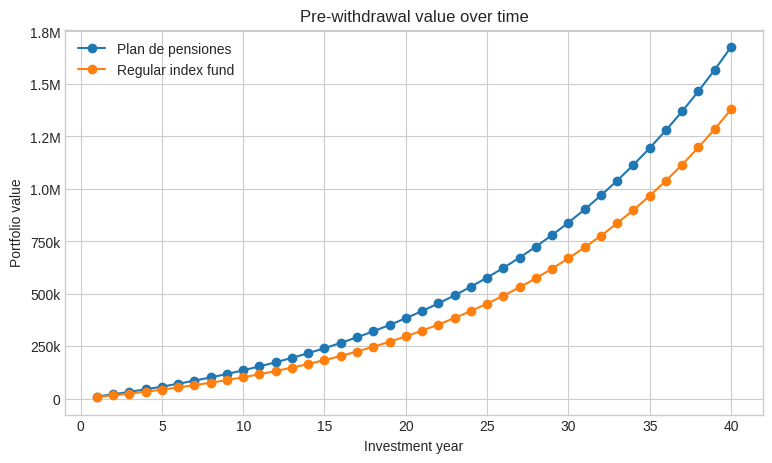

In [4]:
plot_accumulation_history(primary_history)
plt.show()

In [5]:
primary_lump_sum = lump_sum_results(primary_config)
primary_lump_sum

,vehicle,gross_contributed,pre_withdrawal_value,gross_extraction,extraction_tax,extraction_fees,final_after_tax_money,effective_after_tax_cagr
0,Regular index fund,"400,000.00","1,378,364.87","1,378,364.87","311,073.77",0.00,"1,067,291.09",0.02
1,Plan de pensiones,"400,000.00","1,675,620.64","1,675,620.64","748,129.35",0.00,"927,491.28",0.02


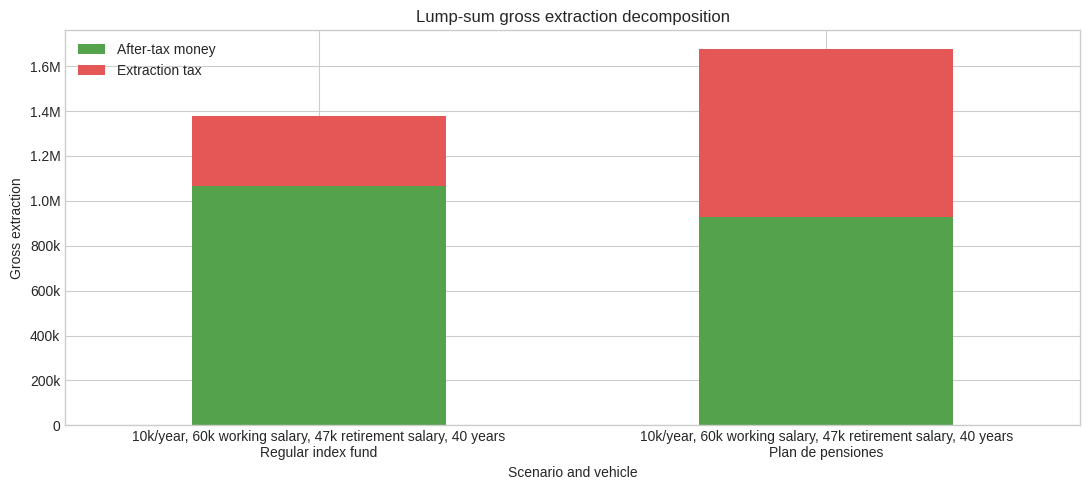

In [6]:
primary_lump_sum_decomposition = normalize_lump_sum_extraction_results(
    primary_lump_sum,
    scenario_name=PRIMARY_SCENARIO["name"],
)
plot_extraction_comparison_breakdown(
    primary_lump_sum_decomposition,
    title="Lump-sum gross extraction decomposition",
)
plt.show()

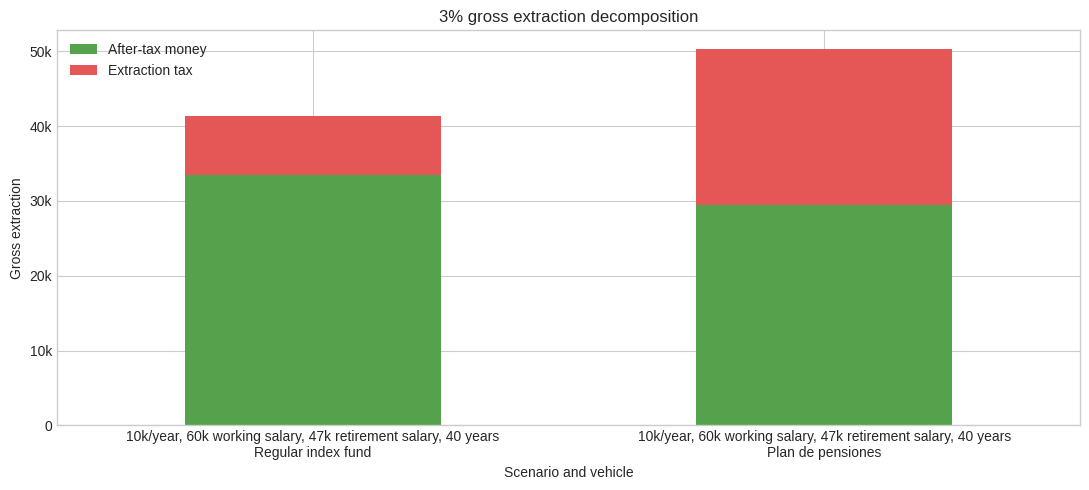

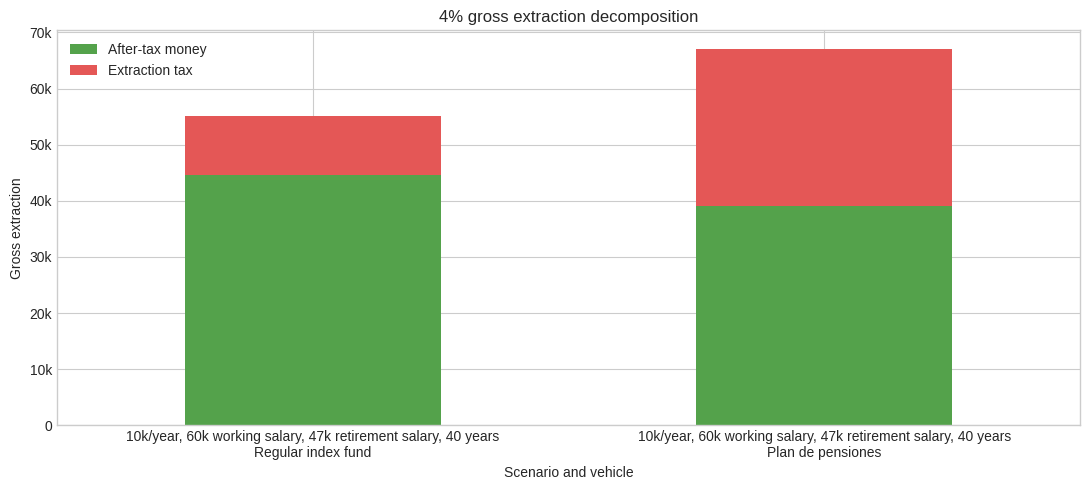

In [7]:
primary_percentage_decompositions = {}
for withdrawal_rate in PRIMARY_SCENARIO["withdrawal_rates"]:
    results = percentage_withdrawal_results(primary_config, withdrawal_rate)
    decomposition = normalize_percentage_extraction_results(
        results,
        scenario_name=PRIMARY_SCENARIO["name"],
    )
    primary_percentage_decompositions[withdrawal_rate] = decomposition
    plot_extraction_comparison_breakdown(
        decomposition,
        title=f"{withdrawal_rate:.0%} gross extraction decomposition",
    )
    plt.show()

In [8]:
salary_experiment_configs = {
    experiment["name"]: build_config(experiment["config"])
    for experiment in SALARY_HEATMAP_EXPERIMENTS
}
salary_heatmap_parameters = {
    experiment["name"]: {"name": experiment["name"], **experiment["heatmap"]}
    for experiment in SALARY_HEATMAP_EXPERIMENTS
}

pd.DataFrame.from_dict(
    {experiment["name"]: experiment["config"] for experiment in SALARY_HEATMAP_EXPERIMENTS},
    orient="index",
)

,annual_contribution,investment_horizon_years,expected_annual_return,annual_return_volatility,regular_fund_annual_fee,pension_plan_annual_fee,regular_entry_fee,regular_exit_fee,pension_entry_fee,pension_exit_fee
Plan de pensiones personal,"1,500.00",40,0.07,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Plan de pensiones de empresa,"8,500.00",40,0.07,0.00,0.00,0.01,0.00,0.00,0.00,0.00


## Working salary vs retirement salary heatmaps

These heatmaps compare salary during working/contribution years against salary before extraction during retirement. The first set is lump-sum extraction; the next sets use 3% and 4% gross withdrawals.


In [9]:
salary_sensitivity_by_mode = {}
salary_heatmap_axes_by_mode = {}

for mode in SALARY_HEATMAP_EXTRACTION_MODES:
    salary_sensitivity_frames = []
    salary_heatmap_axes = {}
    for experiment in SALARY_HEATMAP_EXPERIMENTS:
        name = experiment["name"]
        sensitivity, axes = working_retirement_salary_sensitivity_results(
            {name: salary_experiment_configs[name]},
            {name: salary_heatmap_parameters[name]},
            steps=experiment["heatmap"]["steps"],
            min_model_gross_salary=MIN_MODEL_GROSS_SALARY,
            withdrawal_rate=mode["withdrawal_rate"],
        )
        salary_sensitivity_frames.append(sensitivity)
        salary_heatmap_axes.update(axes)

    salary_sensitivity_by_mode[mode["name"]] = pd.concat(
        salary_sensitivity_frames,
        ignore_index=True,
    )
    salary_heatmap_axes_by_mode[mode["name"]] = salary_heatmap_axes

salary_sensitivity_by_mode["Lump sum"].head()

,scenario,annual_contribution,withdrawal_rate,contribution_salary,withdrawal_salary,pension_advantage
0,Plan de pensiones personal,"1,500.00",None,"1,745.00","1,370.00","-70,950.64"
1,Plan de pensiones personal,"1,500.00",None,"1,745.00","2,110.00","-71,268.84"
2,Plan de pensiones personal,"1,500.00",None,"1,745.00","2,850.00","-71,587.04"
3,Plan de pensiones personal,"1,500.00",None,"1,745.00","3,590.00","-71,905.24"
4,Plan de pensiones personal,"1,500.00",None,"1,745.00","4,330.00","-72,223.44"


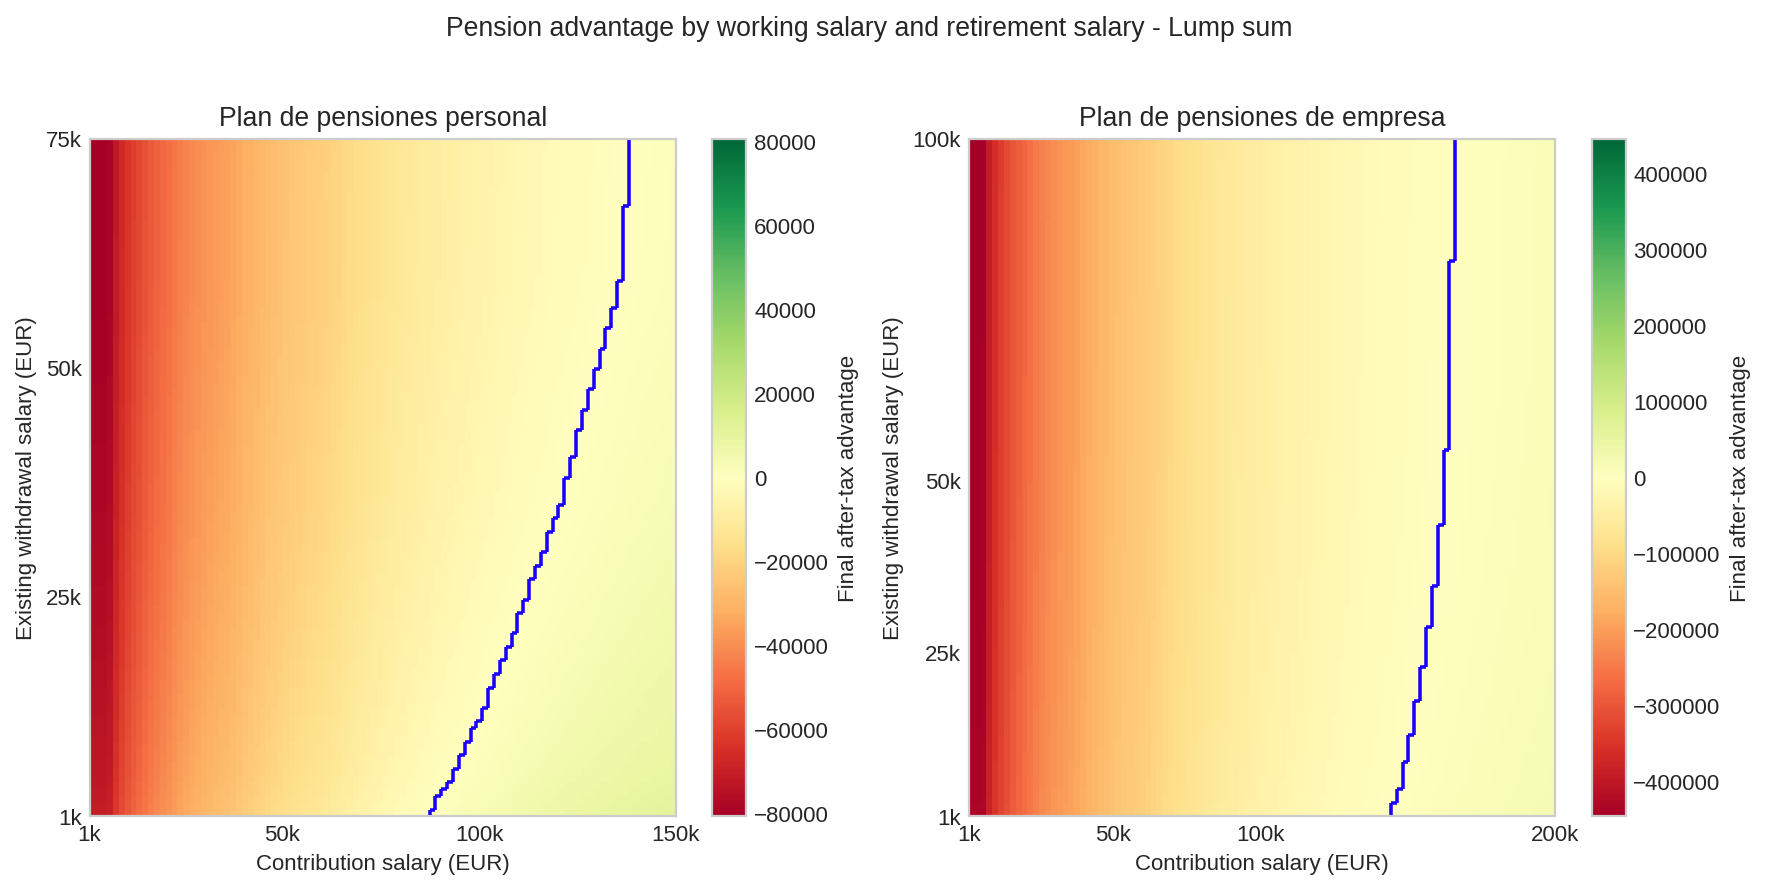

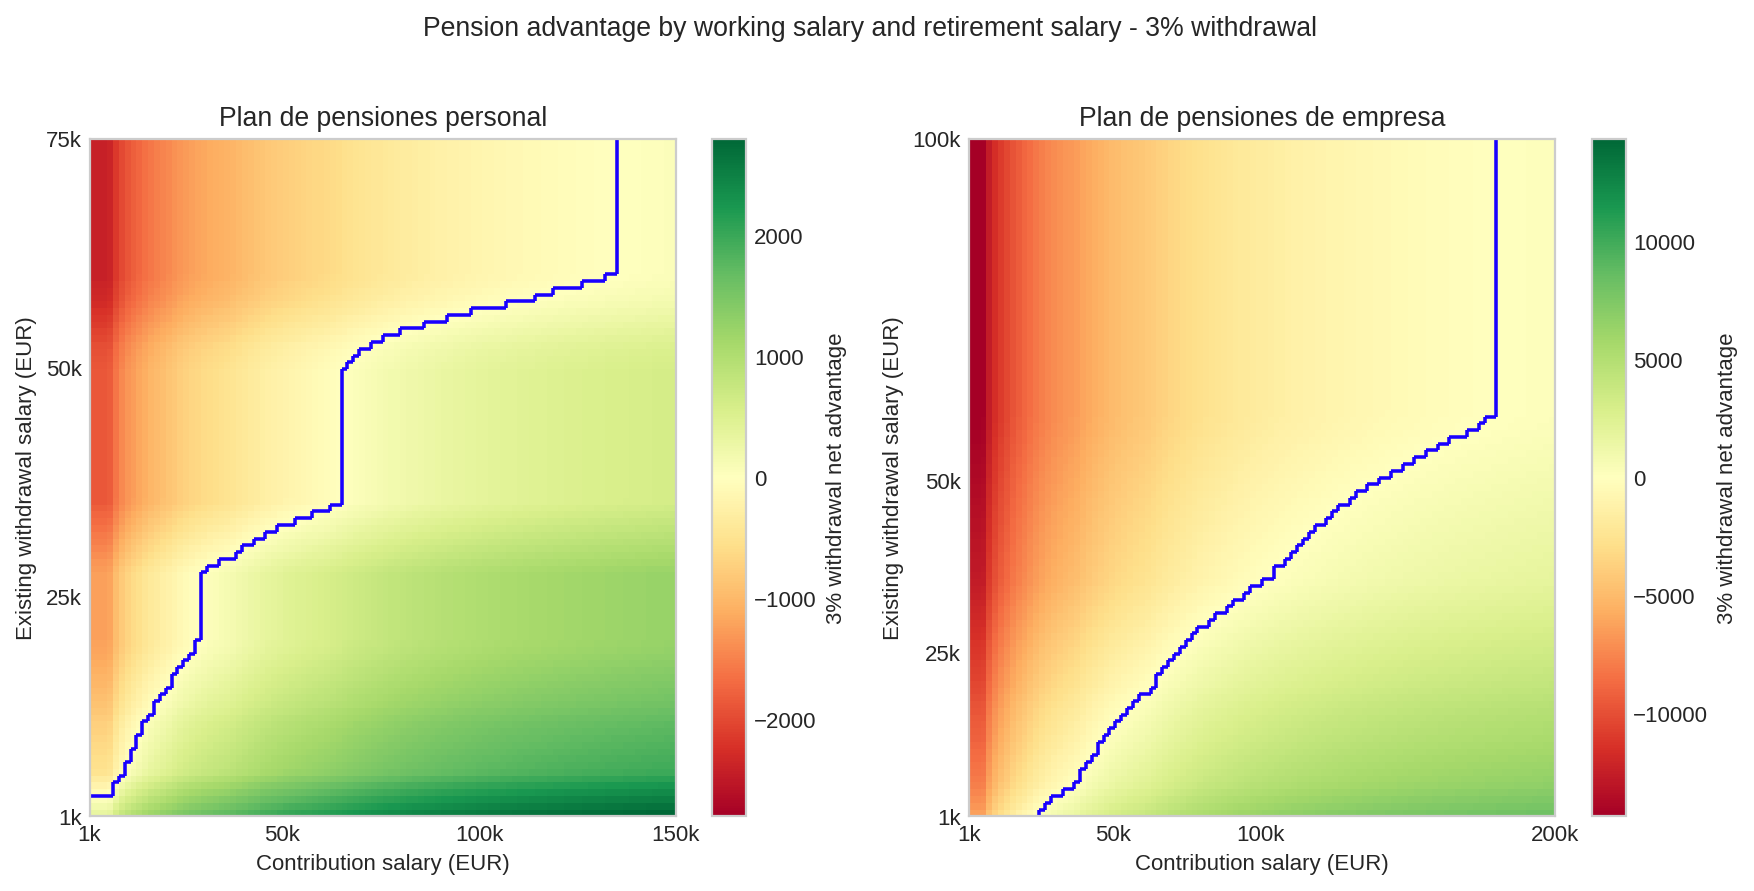

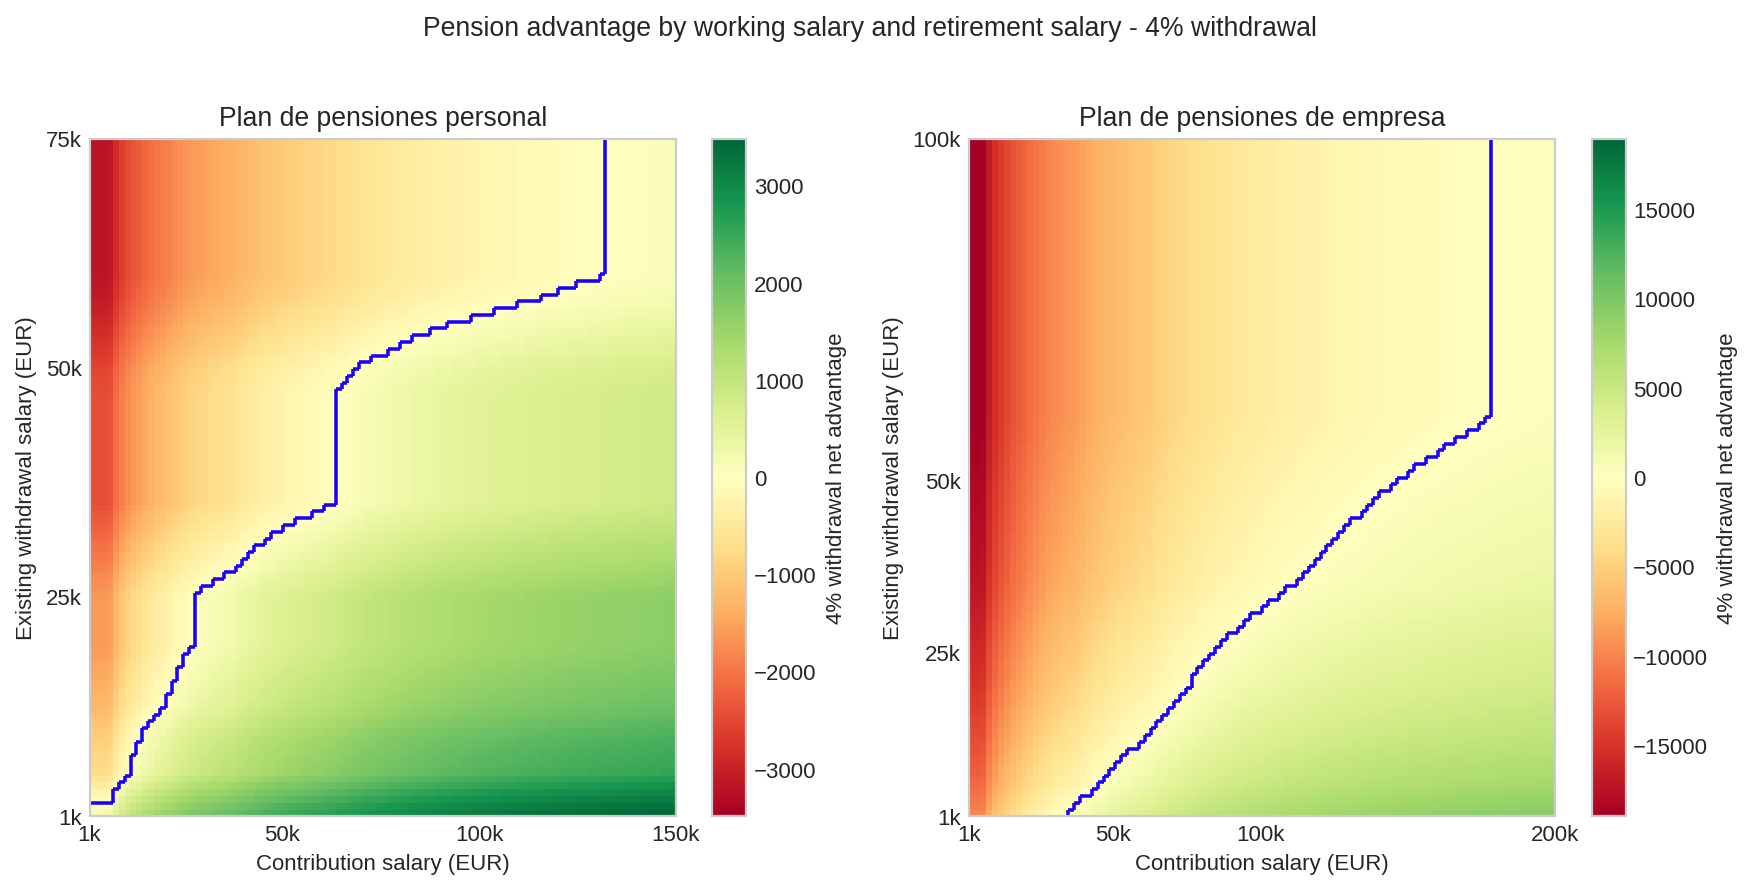

In [10]:
for mode in SALARY_HEATMAP_EXTRACTION_MODES:
    plot_salary_heatmaps(
        list(salary_heatmap_parameters.values()),
        salary_sensitivity_by_mode[mode["name"]],
        salary_heatmap_axes_by_mode[mode["name"]],
        figsize=(13, 5.5),
        colorbar_label=mode["colorbar_label"],
        title=f"Pension advantage by working salary and retirement salary - {mode['name']}",
    )
    plt.show()

## Fee vs annual return sensitivity

Each heatmap value is pension-plan net cash minus regular-index-fund net cash for the configured extraction rate. The heatmaps use dense grids and the blue line marks where the pension advantage changes sign.


In [11]:
fee_return_results = {}
fee_return_axes = {}
for experiment in FEE_RETURN_EXPERIMENTS:
    heatmap = experiment["heatmap"]
    sensitivity, axes = percentage_fee_return_sensitivity_grid_results(
        build_config(experiment["config"]),
        expected_return_min=heatmap["expected_return_min"],
        expected_return_max=heatmap["expected_return_max"],
        pension_fee_premium_min=heatmap["pension_fee_premium_min"],
        pension_fee_premium_max=heatmap["pension_fee_premium_max"],
        steps=heatmap["steps"],
        withdrawal_rate=experiment["withdrawal_rate"],
    )
    fee_return_results[experiment["name"]] = sensitivity
    fee_return_axes[experiment["name"]] = axes

fee_return_results[FEE_RETURN_EXPERIMENTS[0]["name"]].head()

,withdrawal_rate,expected_return,pension_fee_premium,pension_advantage
0,0.03,0.05,0.00,-540.93
1,0.03,0.05,0.00,-566.36
2,0.03,0.05,0.00,-591.76
3,0.03,0.05,0.00,-617.13
4,0.03,0.05,0.00,-642.45


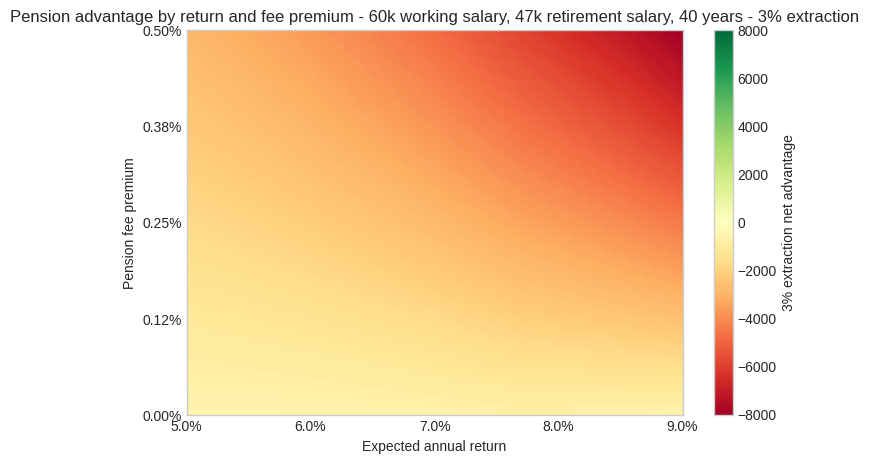

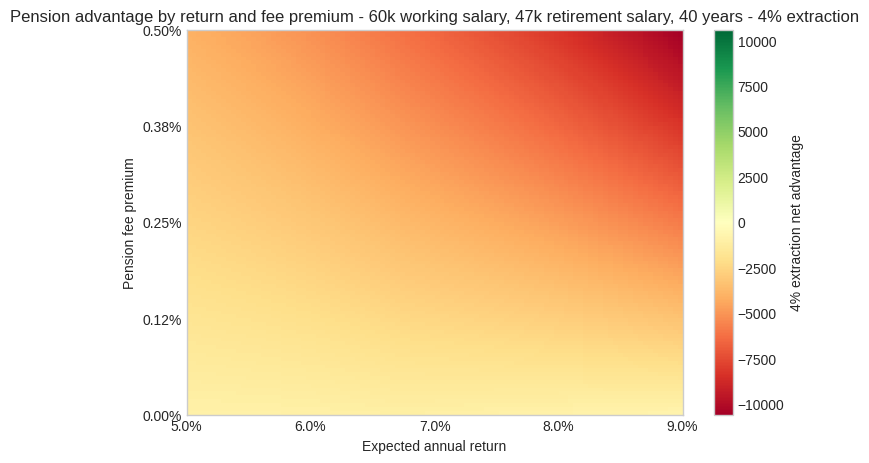

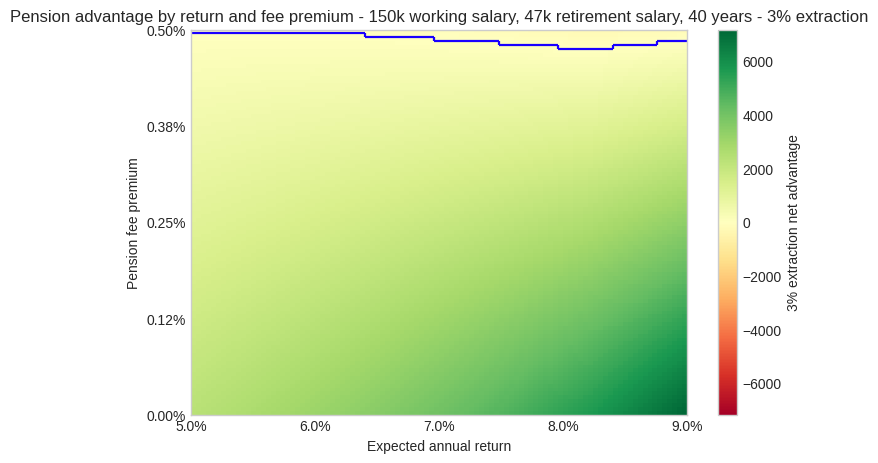

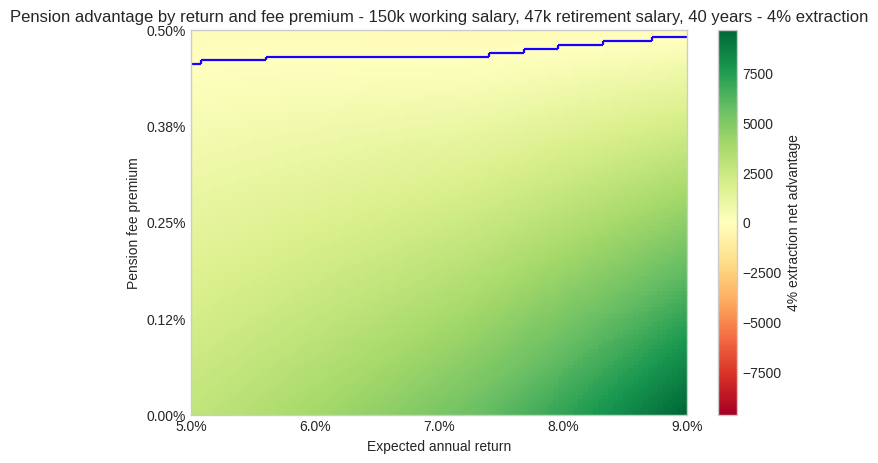

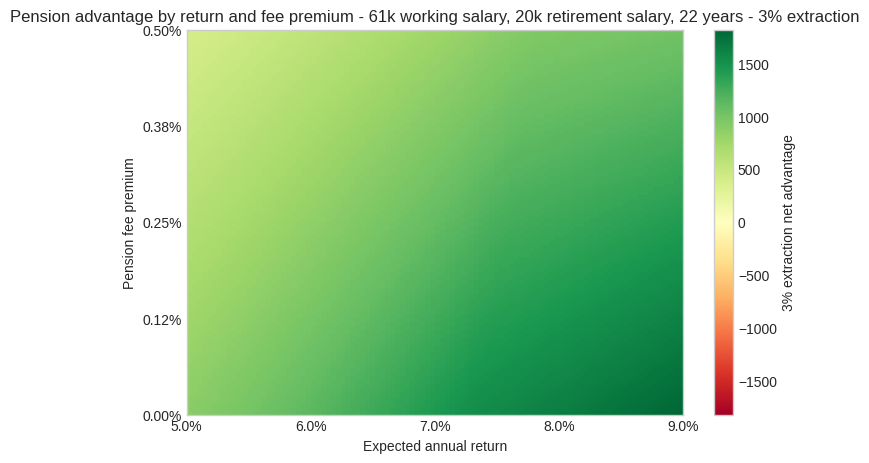

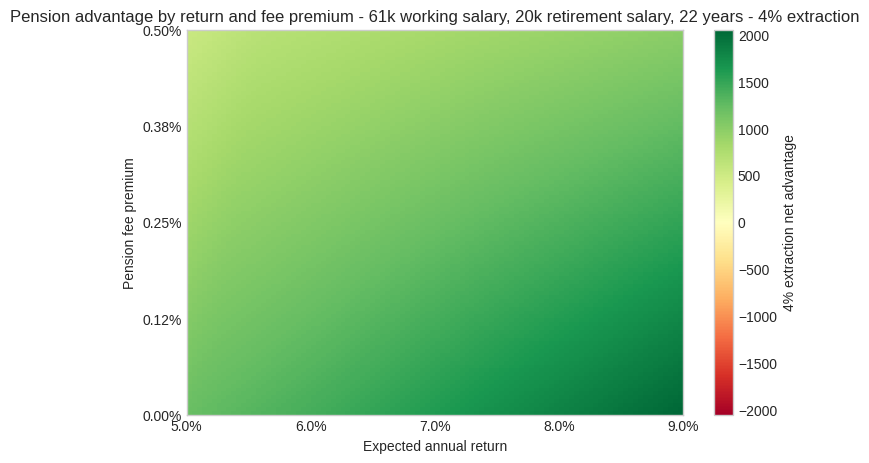

In [12]:
for experiment in FEE_RETURN_EXPERIMENTS:
    heatmap = experiment["heatmap"]
    axes = fee_return_axes[experiment["name"]]
    plot_fee_return_sensitivity(
        fee_return_results[experiment["name"]],
        title=f"Pension advantage by return and fee premium - {experiment['name']}",
        colorbar_label=f"{experiment['withdrawal_rate']:.0%} extraction net advantage",
        expected_return_edges=axes["expected_return_edges"],
        pension_fee_premium_edges=axes["pension_fee_premium_edges"],
        expected_return_ticks=heatmap["expected_return_ticks"],
        pension_fee_premium_ticks=heatmap["pension_fee_premium_ticks"],
    )
    plt.show()

## Final extraction comparison cases

These charts repeat the 3% and 4% gross extraction decomposition for the 150k/47k case and the 23 contribution years plus 17 growth-only years special case.

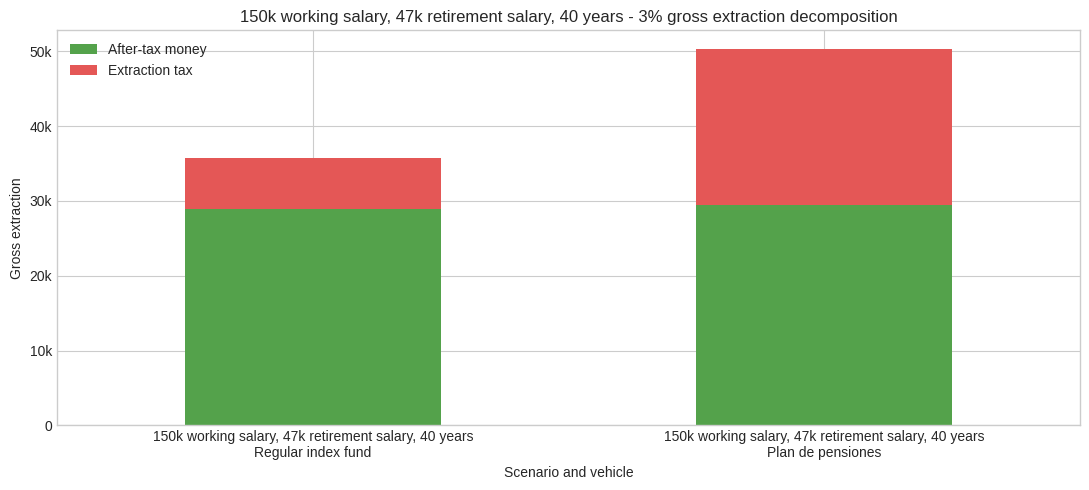

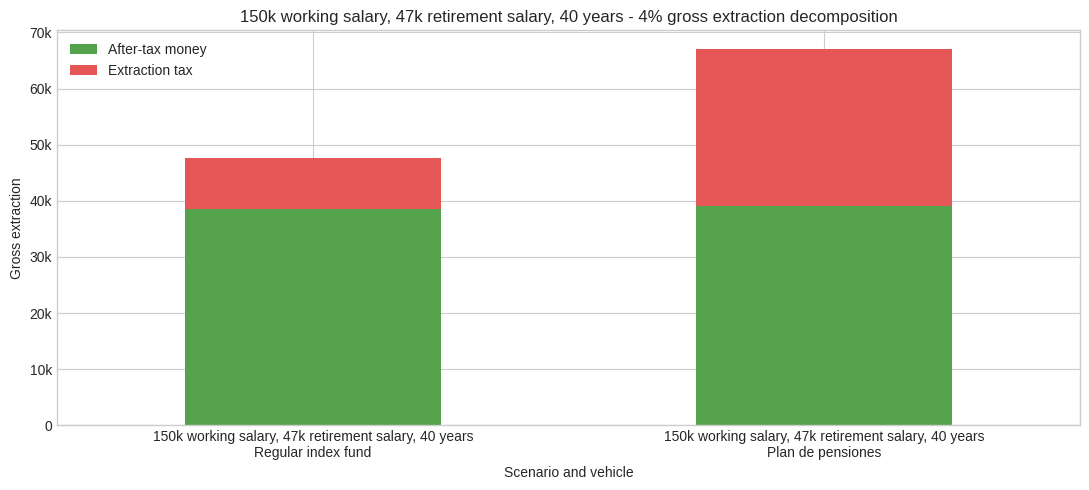

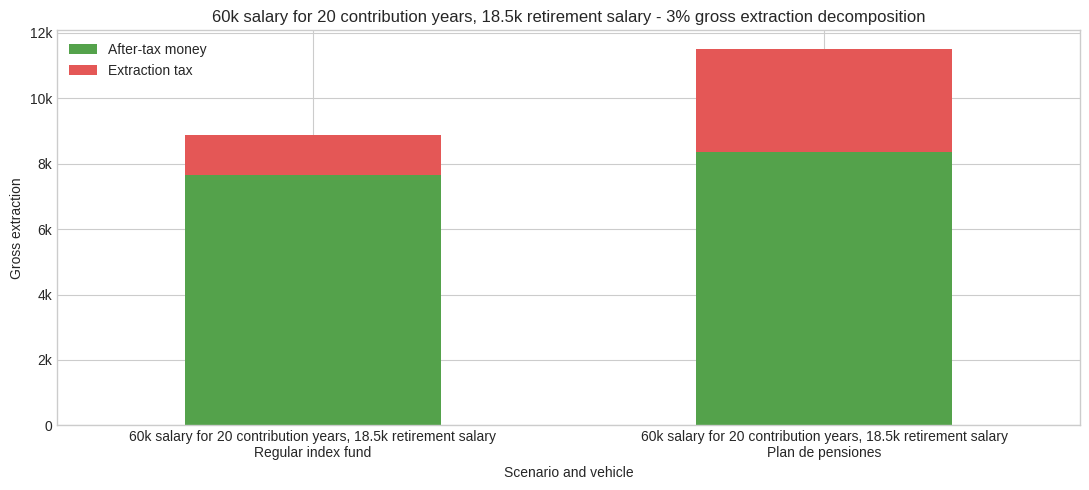

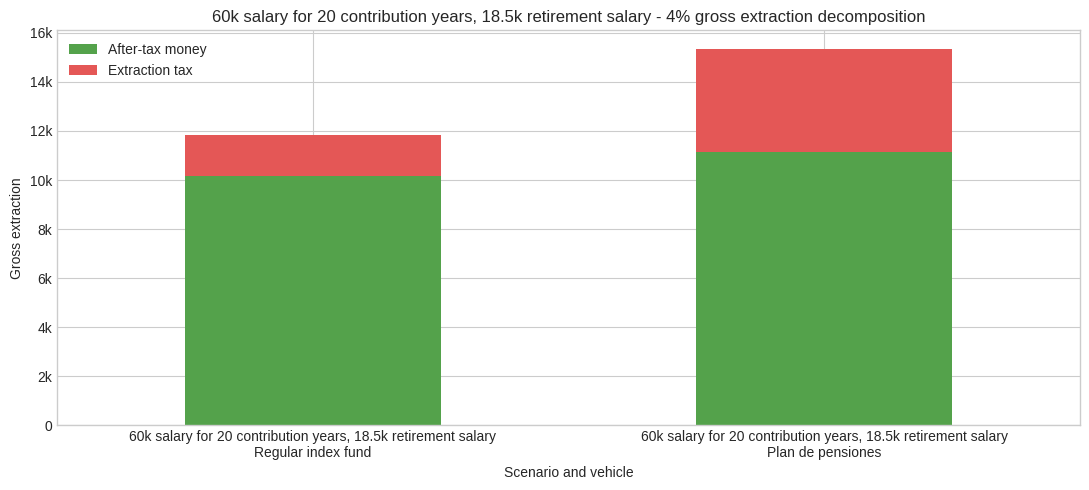

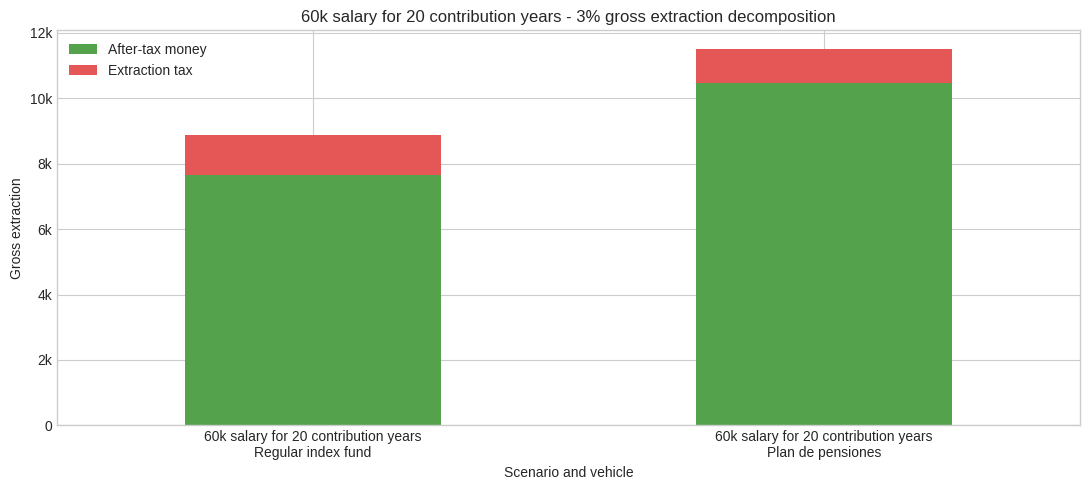

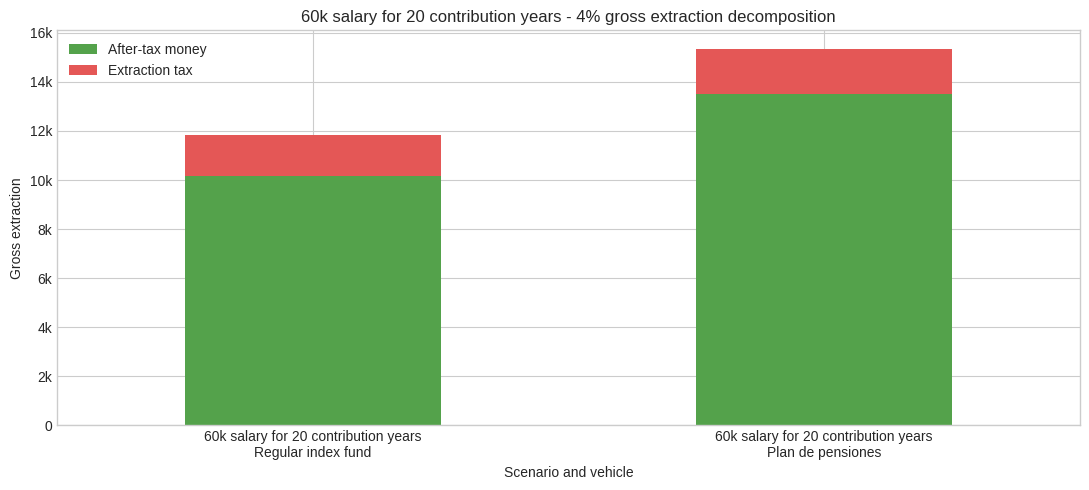

In [13]:
final_case_decompositions = {}
for case in FINAL_EXTRACTION_CASES:
    config = build_config(case["config"])
    for withdrawal_rate in case["withdrawal_rates"]:
        results = percentage_withdrawal_results(config, withdrawal_rate)
        decomposition = normalize_percentage_extraction_results(
            results,
            scenario_name=case["name"],
        )
        final_case_decompositions[(case["name"], withdrawal_rate)] = decomposition
        plot_extraction_comparison_breakdown(
            decomposition,
            title=f"{case['name']} - {withdrawal_rate:.0%} gross extraction decomposition",
        )
        plt.show()